In [1]:
import cv2
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from os.path import dirname, abspath, join
from sys import argv
import sys
import matplotlib.pyplot as plt
import os
from utils import crop_horizontal

In [2]:
# Crear variables difusas
P1 = ctrl.Antecedent(np.arange(0, 256, 1), 'P1')
P2 = ctrl.Antecedent(np.arange(0, 256, 1), 'P2')
P3 = ctrl.Antecedent(np.arange(0, 256, 1), 'P3')
P4 = ctrl.Antecedent(np.arange(0, 256, 1), 'P4')
P4_out = ctrl.Consequent(np.arange(0, 256, 1), 'P4_out')

# Define the adjusted universe of discourse
universe = np.linspace(-800, 800, 100)

# Definir las funciones de pertenencia
for var in [P1, P2, P3, P4, P4_out]:
    #var['low'] = fuzz.zmf(var.universe, 0, 255)
    var['low'] = fuzz.gaussmf(var.universe, 0, 43)
    var['medium'] = fuzz.gaussmf(var.universe, 127, 43)
    #var['high'] = fuzz.smf(var.universe, 0, 255)
    var['high'] = fuzz.gaussmf(var.universe, 255, 43)

In [3]:
#Define the gaussmf function
def gaussmf(x, mean, sigma):
    return np.exp(-((x - mean) ** 2.) / (float(sigma) ** 2.))

In [4]:
# Define the membership functions
def define_mf(mean):
    return {
        'low': gaussmf(universe, 43, 43),
        'medium': gaussmf(universe, 127 , 43),
        'high': gaussmf(universe, 255 , 43)
    }

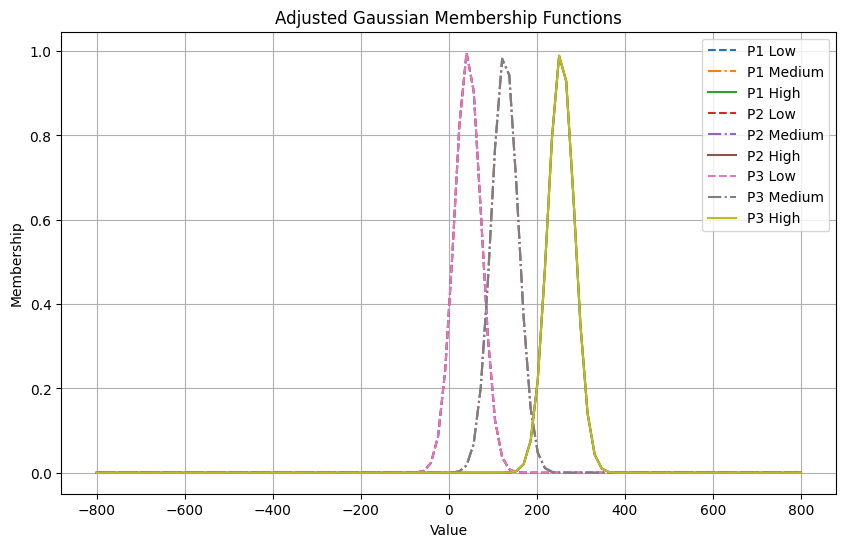

In [5]:
# Define means for P1, P2, P3
P1_mean = 0
P2_mean = 0
P3_mean = 0

# Calculate membership functions
P1_mfs = define_mf(P1_mean)
P2_mfs = define_mf(P2_mean)
P3_mfs = define_mf(P3_mean)

# Plotting the membership functions
plt.figure(figsize=(10, 6))

plt.plot(universe, P1_mfs['low'], label='P1 Low', linestyle='--')
plt.plot(universe, P1_mfs['medium'], label='P1 Medium', linestyle='-.')
plt.plot(universe, P1_mfs['high'], label='P1 High', linestyle='-')

plt.plot(universe, P2_mfs['low'], label='P2 Low', linestyle='--')
plt.plot(universe, P2_mfs['medium'], label='P2 Medium', linestyle='-.')
plt.plot(universe, P2_mfs['high'], label='P2 High', linestyle='-')
plt.plot(universe, P3_mfs['low'], label='P3 Low', linestyle='--')
plt.plot(universe, P3_mfs['medium'], label='P3 Medium', linestyle='-.')
plt.plot(universe, P3_mfs['high'], label='P3 High', linestyle='-')

plt.title('Adjusted Gaussian Membership Functions')
plt.xlabel('Value')
plt.ylabel('Membership')
plt.legend()
plt.grid(True)
plt.show()

# Definir las reglas difusas
rule1 = ctrl.Rule(P1['low'] & P2['low'], P4_out['low'])
rule2 = ctrl.Rule(P1['medium'] & P2['medium'], P4_out['low'])
rule3 = ctrl.Rule(P1['high'] & P2['high'], P4_out['high'])
rule4 = ctrl.Rule(P1['medium'] & P3['low'], P4_out['low'])
rule5 = ctrl.Rule(P2['medium'] & P3['low'], P4_out['low'])
rule6 = ctrl.Rule(P4['low'] & P2['medium'], P4_out['low'])
rule7 = ctrl.Rule(P4['low'] & P1['medium'], P4_out['low'])

# Crear el sistema de control difuso
edge_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
edge_detection = ctrl.ControlSystemSimulation(edge_ctrl)

In [6]:
def detectar_horizonte(image):
    """ Halla la línea del horizonte a través de las colisiones de dos gradientes de color.

    Args:
        image (Image): Imagen del agua

    Returns:
        image, transition_index: retorna la imagen dibujada con la línea del horizonte y la línea completa del horizonte
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred_image = cv2.GaussianBlur(gray, (5, 5), 0)
    gradient = np.gradient(blurred_image, axis=0)
    smoothed_gradient = np.convolve(np.mean(gradient, axis=1), np.ones(15)/15, mode='same')

    transition_index = np.argmax(np.abs(smoothed_gradient))
    print(transition_index)
    horizon_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    if transition_index is not None:
        cv2.line(image, (0, transition_index), (image.shape[1], transition_index), (0, 255, 0), thickness=2)
        horizon_mask[transition_index-2:transition_index+2, :] = 255  # Crear una máscara binaria
    cv2.imshow('horizontada', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    return image, horizon_mask, transition_index

In [7]:
def segment_image(image, horizon_mask):
    rows, cols = image.shape[:2]
    horizon_line = np.argmax(horizon_mask, axis=0)  # Encuentra la línea del horizonte
    
    sea_mask = np.zeros((rows, cols), dtype=np.uint8)
    sky_mask = np.zeros((rows, cols), dtype=np.uint8)
    
    for col in range(cols):
        horizon_row = horizon_line[col]
        sea_mask[horizon_row:, col] = 255
        sky_mask[:horizon_row, col] = 255
    
    return sea_mask, horizon_mask, sky_mask


In [8]:
def detect_horizon(image_path):
    # Cargar la imagen
    print(f"Cargando imagen desde: {image_path}")  # Imprimir la ruta de la imagen para verificación
    image = cv2.imread(image_path)
    # Verificar si la imagen se ha cargado correctamente
    if image is None:
        raise ValueError("La imagen no se pudo cargar. Verifica la ruta del archivo y asegúrate de que el archivo exista.")
    image=cv2.resize(image, (300, 300))

    # Detectar el horizonte
    horizonte_image, horizon_mask, trans = detectar_horizonte(image)

    # Segmentar la imagen en mar, horizonte y cielo
    #sea_mask, horizon_mask, sky_mask = segment_image(image, horizon_mask)
    _,imagen=crop_horizontal(image, trans)

    # Detectar objetos en el mar usando la lógica difusa
    objetos_detectados = detectar_objetos_en_el_mar(imagen)

    # Mostrar la imagen con el horizonte detectado y los objetos
    resized_image = cv2.resize(image, (300, 300))  # Ajustar el tamaño para mejor visualización
    cv2.imshow('Horizon Detection and Object Detection', resized_image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [9]:
def detectar_objetos_en_el_mar(sea_mask):

    if sea_mask is None:
         print("Error: Image not loaded properly.")
    else:
         gray = cv2.cvtColor(sea_mask, cv2.COLOR_BGR2GRAY)
    

    # Aplicar un filtro Gaussiano para reducir el ruido
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    #rezides=cv2.resize(gray, (300,300))
        # Convertir la imagen a escala de grises
    
    # Aplicar la máscara del mar
    # sea_region = cv2.bitwise_and(sea_mask, sea_mask, mask=sea_mask)
    cv2.imshow('mascara mar', gray)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # Crear una imagen para guardar los bordes difusos
    fuzzy_edge_image = np.zeros_like(gray, dtype=np.uint8)
    

    # Obtener las dimensiones de la imagen
    height, width = gray.shape

    # Recorrer cada píxel de la imagen
    for y in range(0, height - 1):
        for x in range(0, width - 1):
            # Obtener los valores de los píxeles vecinos
            pixel_P1 = gray[y, x]
            pixel_P2 = gray[y, x + 1]
            pixel_P3 = gray[y + 1, x]
            pixel_P4 = gray[y + 1, x + 1]

            # Asignar los valores a las variables difusas
            edge_detection.input['P1'] = pixel_P1
            edge_detection.input['P2'] = pixel_P2
            edge_detection.input['P3'] = pixel_P3
            edge_detection.input['P4'] = pixel_P4

            # Calcular el valor de salida
            edge_detection.compute()
            fuzzy_edge_image[y + 1, x + 1] = edge_detection.output['P4_out']


        # Dibujar los contornos en la imagen original

            # Umbralizar la imagen resultante para obtener los contornos
    _, thresh = cv2.threshold(fuzzy_edge_image, 127, 255, cv2.THRESH_BINARY)

        # Encontrar los contornos
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        # Aplicar la máscara del mar
    print(fuzzy_edge_image)
    #contours = cv2.bitwise_and(rezides, rezides, mask=fuzzy_edge_image)
    cv2.imshow('contours', fuzzy_edge_image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    rezides2=cv2.resize(sea_mask, (300, 300))
    contour_image = sea_mask.copy()
    #blended = cv2.addWeighted(contours, 0.5, contour_image, 0.5, 0)
    #cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)   #no
    # Mostrar la imagen con los contornos detectados
    #cv2.imshow('contours', blended)
    cv2.imshow('contours2', contour_image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    



In [11]:
if __name__ == "__main__":

    # Ruta a la imagen
#    if len(argv) > 1:
#        filename = join(dirname(dirname(abspath(__file__))), f"img/{argv[1]}")
#    else:
#        filename = join(dirname(dirname(abspath(__file__))), "img/ypacarai.jpeg")
    #filename = "Users/Koki/detector-obstaculos-logica-difusa/detector-obstaculos-logica-difusa/img/ypacarai.jpeg"
    filename = "imagen_segmentada_guardada.png"  # Ruta simplificada
    absolute_path = os.path.abspath(filename)
    print("Ruta absoluta del archivo:", absolute_path)
    if not os.path.exists(absolute_path):
        raise ValueError("La imagen no se pudo cargar. Verifica la ruta del archivo y asegúrate de que el archivo exista.")
    image = cv2.imread(absolute_path)

    detect_horizon(absolute_path)



Ruta absoluta del archivo: c:\Users\Koki\detector-obstaculos-logica-difusa\detector-obstaculos-logica-difusa\src\imagen_segmentada_guardada.png
Cargando imagen desde: c:\Users\Koki\detector-obstaculos-logica-difusa\detector-obstaculos-logica-difusa\src\imagen_segmentada_guardada.png
126
[[  0   0   0 ...   0   0   0]
 [  0  51  51 ...  51  51  51]
 [  0  51  51 ...  51  51  51]
 ...
 [  0 216 216 ... 169  41  38]
 [  0 216 216 ... 216 204  57]
 [  0 216 216 ... 208 216 216]]


In [21]:
# Imprimir el directorio actual
print("Directorio actual:", os.getcwd())

# Listar archivos en el directorio actual
print("Archivos en el directorio actual:", os.listdir('.'))
sys.path.append(os.path.abspath('src'))

Directorio actual: /home/lozorio/detector-obstaculos-logica-difusa-2
Archivos en el directorio actual: ['requirements.txt', 'docs', 'img', 'tests', 'output_image.jpg', 'resultados', 'main.py', 'test.jpeg', 'install.fish', '.gitignore', 'install.ps1', 'README.md', 'notebooks', '.venv', 'videos', '.git', 'src']
